# Bank Marketing Campaign — Analyse Marketing Data
## Partie 1 : Audit de la Campagne Existante

> **Problématique** : Comment optimiser le ciblage et le timing d'une campagne de télémarketing pour maximiser le taux de conversion tout en réduisant le coût par contact ?

---
**Auteur** : Malcom Closse — Marketing Data Analyst  
**Dataset** : Bank Marketing Dataset (UCI / Kaggle)  
**Stack** : Python · Pandas · Matplotlib · Seaborn

---
## Import des librairies & configuration

In [41]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.ticker as mtick
import seaborn as sns
import warnings
import sys
import os

warnings.filterwarnings("ignore")

# Ajouter le dossier scripts au path
sys.path.append(os.path.join("..", "scripts"))

# Style global des graphiques
sns.set_theme(style="whitegrid", palette="muted")
plt.rcParams.update(
    {
        "figure.dpi": 130,
        "axes.titlesize": 14,
        "axes.titleweight": "bold",
        "axes.titlepad": 14,
        "axes.labelsize": 11,
        "xtick.labelsize": 10,
        "ytick.labelsize": 10,
        "figure.figsize": (12, 5),
    }
)

# Palette métier
COLOR_YES = "#1D9E75"  # Vert — client converti
COLOR_NO = "#D85A30"  # Rouge — non converti
COLOR_BASE = "#378ADD"  # Bleu — neutre
COLORS_DUAL = [COLOR_YES, COLOR_NO]

print("Librairies chargées avec succès")
print(f"   Pandas  {pd.__version__}")
print(f"   NumPy   {np.__version__}")
print(f"   Seaborn {sns.__version__}")

Librairies chargées avec succès
   Pandas  2.2.2
   NumPy   1.26.4
   Seaborn 0.13.2


---
## Chargement des données

In [43]:
# Chemin vers le dataset brut
DATA_PATH = os.path.join("..", "data", "raw", "bank.csv")

df_raw = pd.read_csv(DATA_PATH)

print(f"Dataset chargé : {df_raw.shape[0]:,} lignes × {df_raw.shape[1]} colonnes")
df_raw.head()

Dataset chargé : 11,162 lignes × 17 colonnes


,age,job,marital,education,default,balance,housing,loan,contact,day,month,duration,campaign,pdays,previous,poutcome,deposit
0,59,admin.,married,secondary,no,2343,yes,no,unknown,5,may,1042,1,-1,0,unknown,yes
1,56,admin.,married,secondary,no,45,no,no,unknown,5,may,1467,1,-1,0,unknown,yes
2,41,technician,married,secondary,no,1270,yes,no,unknown,5,may,1389,1,-1,0,unknown,yes
3,55,services,married,secondary,no,2476,yes,no,unknown,5,may,579,1,-1,0,unknown,yes
4,54,admin.,married,tertiary,no,184,no,no,unknown,5,may,673,2,-1,0,unknown,yes


---
## Dictionnaire des variables

| Variable | Type | Description |
|----------|------|-------------|
| `age` | int | Âge du client |
| `job` | cat | Catégorie socio-professionnelle |
| `marital` | cat | Statut marital |
| `education` | cat | Niveau d'éducation |
| `default` | bin | Défaut de crédit (yes/no) |
| `balance` | int | Solde annuel moyen (€) |
| `housing` | bin | Prêt immobilier (yes/no) |
| `loan` | bin | Prêt personnel (yes/no) |
| `contact` | cat | Canal de contact (cellular/telephone/unknown) |
| `day` | int | Jour du mois du dernier contact |
| `month` | cat | Mois du dernier contact |
| `duration` | int | Durée du dernier appel (secondes) |
| `campaign` | int | Nb de contacts durant cette campagne |
| `pdays` | int | Nb de jours depuis le dernier contact (-1 = jamais) |
| `previous` | int | Nb de contacts avant cette campagne |
| `poutcome` | cat | Résultat de la campagne précédente |
| `deposit` | bin | **Cible** : souscription dépôt à terme (yes/no) |

---
## Nettoyage & préparation des données

In [42]:
df = df_raw.copy()

# --- Renommage de la cible ---
df.rename(columns={"deposit": "subscribed"}, inplace=True)

# --- Variable cible binaire (utile pour les moyennes) ---
df["subscribed_bin"] = (df["subscribed"] == "yes").astype(int)

# --- Remplacement des 'unknown' par NaN ---
df.replace("unknown", np.nan, inplace=True)

# --- Traitement de pdays : -1 signifie 'jamais contacté' ---
df["never_contacted"] = (df["pdays"] == -1).astype(int)
df["pdays"] = df["pdays"].replace(-1, np.nan)

# --- Ordre calendaire des mois ---
MONTH_ORDER = [
    "jan",
    "feb",
    "mar",
    "apr",
    "may",
    "jun",
    "jul",
    "aug",
    "sep",
    "oct",
    "nov",
    "dec",
]
df["month"] = pd.Categorical(df["month"], categories=MONTH_ORDER, ordered=True)

print(f"Données nettoyées : {df.shape[0]:,} lignes × {df.shape[1]} colonnes")
print("   Variables créées  : subscribed_bin, never_contacted")
df.dtypes

Données nettoyées : 11,162 lignes × 19 colonnes
   Variables créées  : subscribed_bin, never_contacted


age                   int64
job                  object
marital              object
education            object
default              object
balance               int64
housing              object
loan                 object
contact              object
day                   int64
month              category
duration              int64
campaign              int64
pdays               float64
previous              int64
poutcome             object
subscribed           object
subscribed_bin        int64
never_contacted       int64
dtype: object

---
## Vue d'ensemble & qualité des données

In [26]:
# --- Statistiques descriptives ---
print("=== STATISTIQUES DESCRIPTIVES ===")
df.describe(include="all").T


=== STATISTIQUES DESCRIPTIVES ===


,count,unique,top,freq,mean,std,min,25%,50%,75%,max
age,11162.0,NaN,NaN,NaN,41.231948,11.913369,18.0,32.0,39.0,49.0,95.0
job,11092,11,management,2566,NaN,NaN,NaN,NaN,NaN,NaN,NaN
marital,11162,3,married,6351,NaN,NaN,NaN,NaN,NaN,NaN,NaN
education,10665,3,secondary,5476,NaN,NaN,NaN,NaN,NaN,NaN,NaN
default,11162,2,no,10994,NaN,NaN,NaN,NaN,NaN,NaN,NaN
balance,11162.0,NaN,NaN,NaN,1528.538524,3225.413326,-6847.0,122.0,550.0,1708.0,81204.0
housing,11162,2,no,5881,NaN,NaN,NaN,NaN,NaN,NaN,NaN
loan,11162,2,no,9702,NaN,NaN,NaN,NaN,NaN,NaN,NaN
contact,8816,2,cellular,8042,NaN,NaN,NaN,NaN,NaN,NaN,NaN
day,11162.0,NaN,NaN,NaN,15.658036,8.42074,1.0,8.0,15.0,22.0,31.0


In [27]:
# --- Audit des valeurs manquantes ---
missing = df.isnull().sum()
missing_pct = (missing / len(df) * 100).round(2)
missing_df = pd.DataFrame({"Valeurs manquantes": missing, "% du total": missing_pct})
missing_df = missing_df[missing_df["Valeurs manquantes"] > 0].sort_values(
    "% du total", ascending=False
)

if missing_df.empty:
    print("Aucune valeur manquante détectée (hors unknown remplacés par NaN)")
else:
    print("⚠️  Valeurs manquantes détectées :")
    display(missing_df)

# --- Doublons ---
dupes = df.duplicated().sum()
print(f"\n Doublons : {dupes} ({dupes / len(df) * 100:.2f}% du dataset)")

⚠️  Valeurs manquantes détectées :


,Valeurs manquantes,% du total
poutcome,8326,74.59
pdays,8324,74.57
contact,2346,21.02
education,497,4.45
job,70,0.63



 Doublons : 0 (0.00% du dataset)


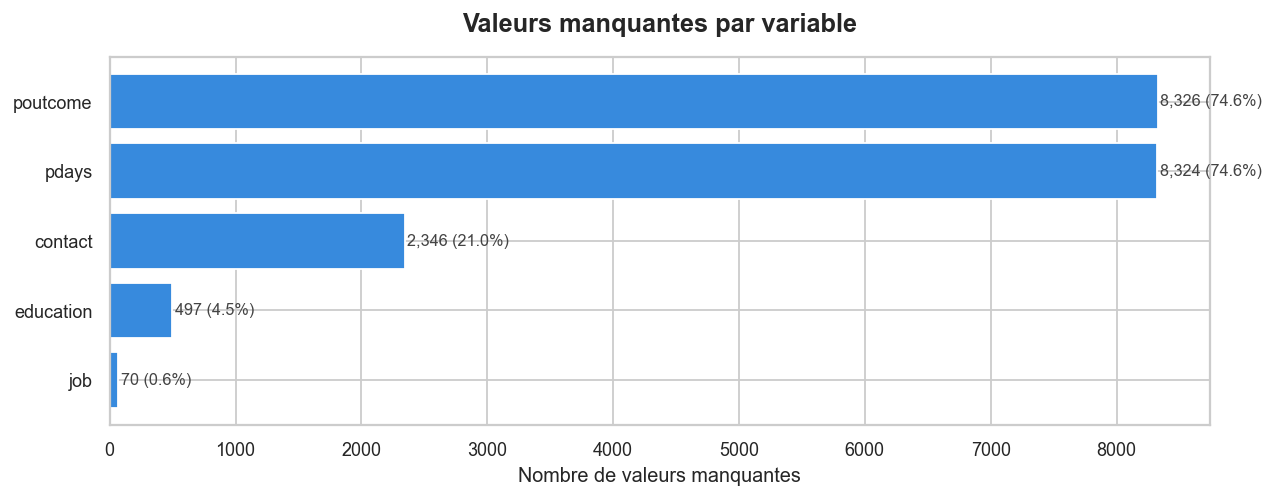

In [ ]:
# --- Visualisation des valeurs manquantes ---
missing_plot = df.isnull().sum()
missing_plot = missing_plot[missing_plot > 0].sort_values(ascending=True)

if not missing_plot.empty:
    fig, ax = plt.subplots(figsize=(10, 4))
    bars = ax.barh(
        missing_plot.index, missing_plot.values, color=COLOR_BASE, edgecolor="white"
    )
    for bar, val in zip(bars, missing_plot.values):
        ax.text(
            val + 20,
            bar.get_y() + bar.get_height() / 2,
            f"{val:,} ({val / len(df) * 100:.1f}%)",
            va="center",
            fontsize=9,
            color="#444",
        )
    ax.set_title("Valeurs manquantes par variable")
    ax.set_xlabel("Nombre de valeurs manquantes")
    plt.tight_layout()
    plt.savefig(
        os.path.join("..", "outputs", "figures", "00_missing_values.png"),
        dpi=150,
        bbox_inches="tight",
    )
    plt.show()
else:
    print("Pas de valeurs manquantes à visualiser")

---
## Taux de conversion global

> Point de départ de toute l'analyse : combien de clients ont souscrit ?

In [14]:
# --- KPI global ---
total = len(df)
total_yes = df["subscribed_bin"].sum()
total_no = total - total_yes
conv_rate = total_yes / total * 100

print("=" * 45)
print("   KPI GLOBAUX DE LA CAMPAGNE")
print("=" * 45)
print(f"   Total contacts       : {total:>10,}")
print(f"   Conversions (yes)    : {total_yes:>10,}  ({conv_rate:.1f}%)")
print(f"   Non-conversions (no) : {total_no:>10,}  ({100 - conv_rate:.1f}%)")
print("=" * 45)

   KPI GLOBAUX DE LA CAMPAGNE
   Total contacts       :     11,162
   Conversions (yes)    :      5,289  (47.4%)
   Non-conversions (no) :      5,873  (52.6%)


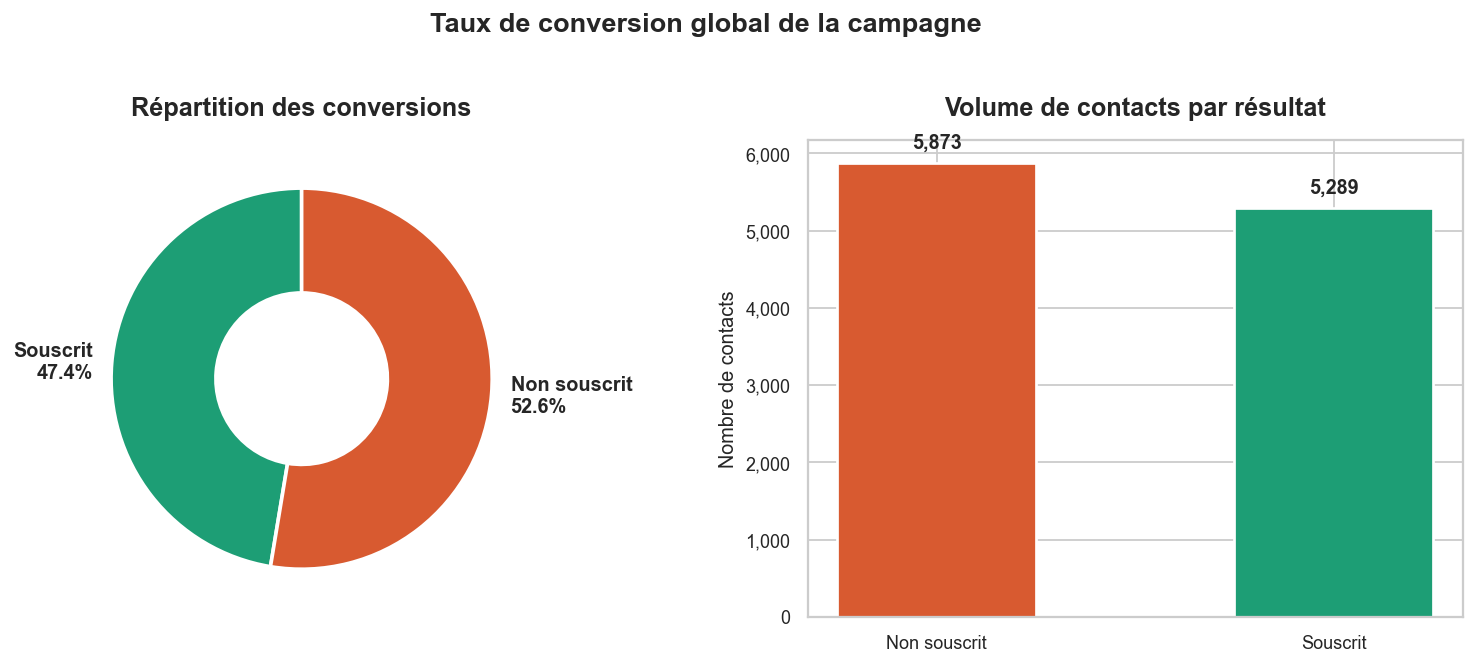

In [15]:
# --- Visualisation taux de conversion global ---
fig, axes = plt.subplots(1, 2, figsize=(12, 5))

# Donut chart
sizes = [total_yes, total_no]
labels = [f"Souscrit\n{conv_rate:.1f}%", f"Non souscrit\n{100 - conv_rate:.1f}%"]
wedges, texts = axes[0].pie(
    sizes,
    labels=labels,
    colors=COLORS_DUAL,
    startangle=90,
    wedgeprops=dict(width=0.55, edgecolor="white", linewidth=2),
)
for text in texts:
    text.set_fontsize(11)
    text.set_fontweight("bold")
axes[0].set_title("Répartition des conversions")

# Barres absolues
bars = axes[1].bar(
    ["Non souscrit", "Souscrit"],
    [total_no, total_yes],
    color=[COLOR_NO, COLOR_YES],
    edgecolor="white",
    linewidth=1.5,
    width=0.5,
)
for bar, val in zip(bars, [total_no, total_yes]):
    axes[1].text(
        bar.get_x() + bar.get_width() / 2,
        bar.get_height() + 200,
        f"{val:,}",
        ha="center",
        fontweight="bold",
        fontsize=11,
    )
axes[1].set_title("Volume de contacts par résultat")
axes[1].set_ylabel("Nombre de contacts")
axes[1].yaxis.set_major_formatter(mtick.FuncFormatter(lambda x, _: f"{int(x):,}"))

plt.suptitle(
    "Taux de conversion global de la campagne", fontsize=15, fontweight="bold", y=1.02
)
plt.tight_layout()
plt.savefig(
    os.path.join("..", "outputs", "figures", "01_conversion_globale.png"),
    dpi=150,
    bbox_inches="tight",
)
plt.show()

---
## Taux de conversion par segment client

> Qui convertit le mieux ? Analyse par job, âge, éducation, statut marital.

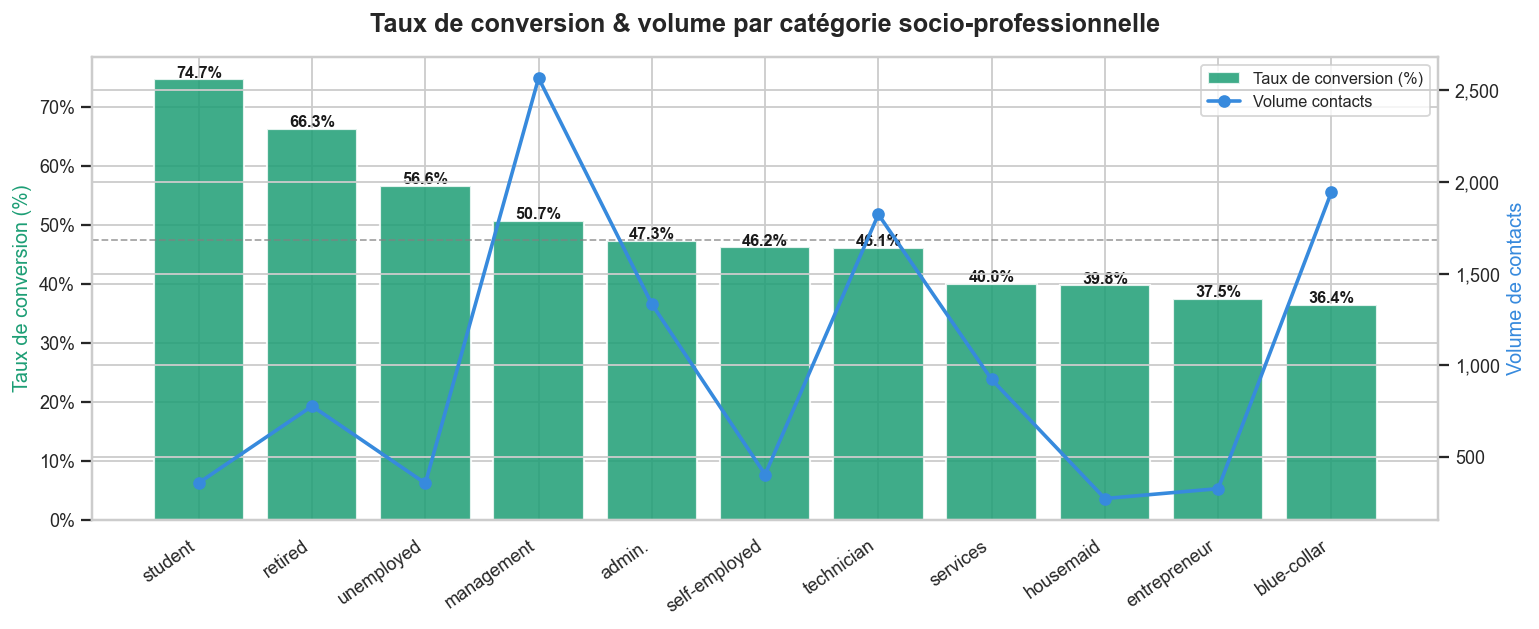


 Détail :


,nb_contacts,conversions,taux
job,,,
student,360,269,74.722222
retired,778,516,66.323907
unemployed,357,202,56.582633
management,2566,1301,50.701481
admin.,1334,631,47.301349
self-employed,405,187,46.172840
technician,1823,840,46.077894
services,923,369,39.978332
housemaid,274,109,39.781022


In [30]:
def plot_conversion_by_cat(df, col, title, top_n=None, figsize=(12, 5), save_name=None):
    """Taux de conversion et volume par catégorie — double axe."""
    grp = (
        df.groupby(col)
        .agg(
            nb_contacts=("subscribed_bin", "count"),
            conversions=("subscribed_bin", "sum"),
        )
        .assign(taux=lambda x: x["conversions"] / x["nb_contacts"] * 100)
        .sort_values("taux", ascending=False)
    )
    if top_n:
        grp = grp.head(top_n)

    fig, ax1 = plt.subplots(figsize=figsize)
    ax2 = ax1.twinx()

    x = range(len(grp))
    bars = ax1.bar(
        x,
        grp["taux"],
        color=COLOR_YES,
        alpha=0.85,
        edgecolor="white",
        linewidth=1.2,
        label="Taux de conversion (%)",
    )
    ax2.plot(
        x,
        grp["nb_contacts"],
        color=COLOR_BASE,
        marker="o",
        linewidth=2,
        markersize=6,
        label="Volume contacts",
    )

    # Annotations taux
    for bar, val in zip(bars, grp["taux"]):
        ax1.text(
            bar.get_x() + bar.get_width() / 2,
            bar.get_height() + 0.3,
            f"{val:.1f}%",
            ha="center",
            fontsize=9,
            fontweight="bold",
            color="#1a1a1a",
        )

    ax1.set_xticks(list(x))
    ax1.set_xticklabels(grp.index, rotation=35, ha="right")
    ax1.set_ylabel("Taux de conversion (%)", color=COLOR_YES)
    ax1.yaxis.set_major_formatter(mtick.FuncFormatter(lambda y, _: f"{y:.0f}%"))
    ax2.set_ylabel("Volume de contacts", color=COLOR_BASE)
    ax2.yaxis.set_major_formatter(mtick.FuncFormatter(lambda y, _: f"{int(y):,}"))

    lines1, labels1 = ax1.get_legend_handles_labels()
    lines2, labels2 = ax2.get_legend_handles_labels()
    ax1.legend(lines1 + lines2, labels1 + labels2, loc="upper right", fontsize=9)
    ax1.set_title(title)
    ax1.axhline(
        df["subscribed_bin"].mean() * 100,
        color="gray",
        linestyle="--",
        linewidth=1,
        alpha=0.7,
        label=f"Moyenne globale",
    )
    plt.tight_layout()
    if save_name:
        plt.savefig(
            os.path.join("..", "outputs", "figures", save_name),
            dpi=150,
            bbox_inches="tight",
        )
    plt.show()
    return grp


# --- Par job ---
grp_job = plot_conversion_by_cat(
    df,
    "job",
    title="Taux de conversion & volume par catégorie socio-professionnelle",
    save_name="02_conversion_par_job.png",
)
print("\n Détail :")
display(grp_job)

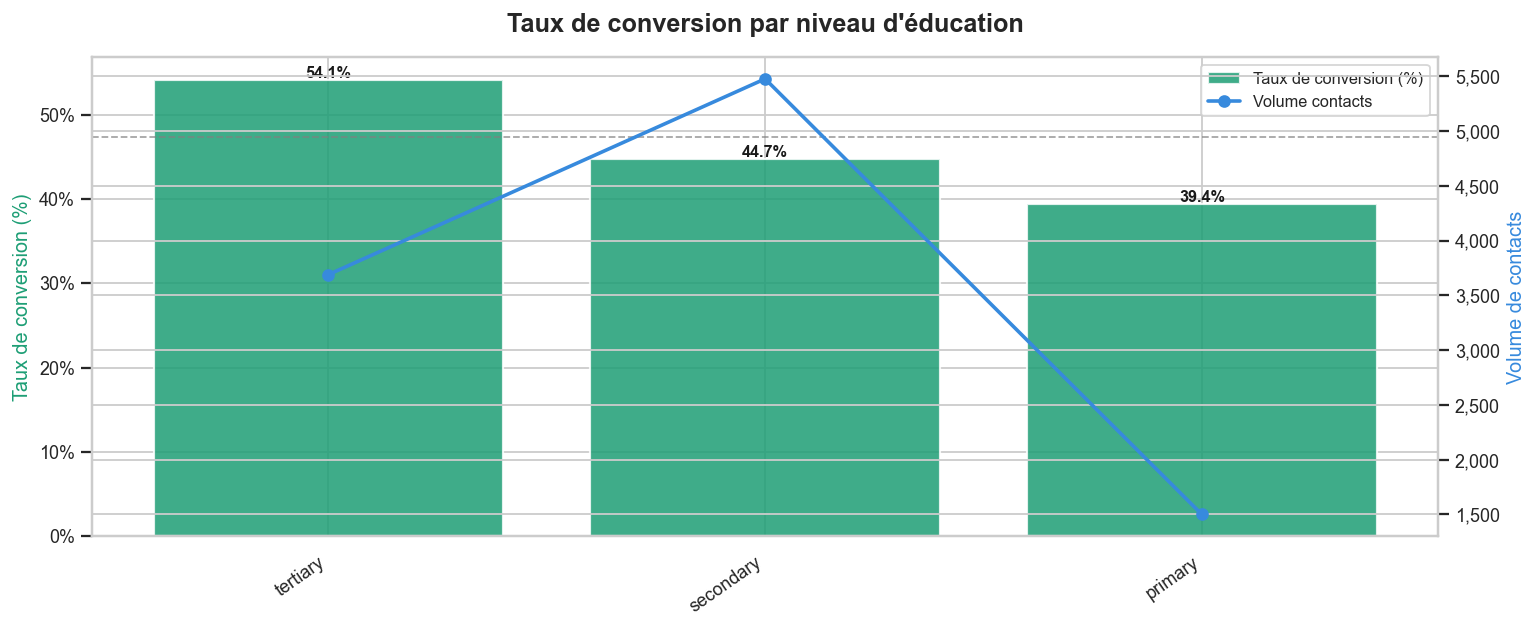

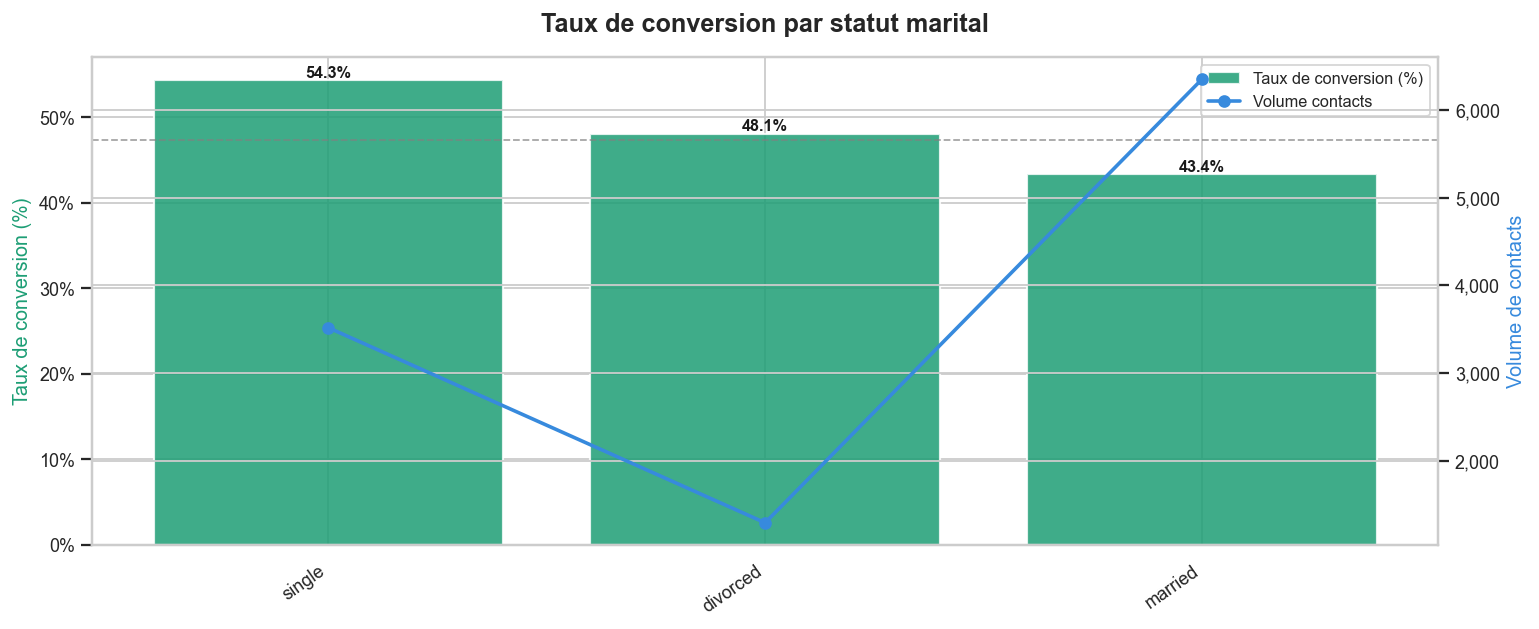

In [17]:
# --- Par niveau d'éducation ---
grp_edu = plot_conversion_by_cat(
    df,
    "education",
    title="Taux de conversion par niveau d'éducation",
    save_name="03_conversion_par_education.png",
)

# --- Par statut marital ---
grp_marital = plot_conversion_by_cat(
    df,
    "marital",
    title="Taux de conversion par statut marital",
    save_name="04_conversion_par_marital.png",
)

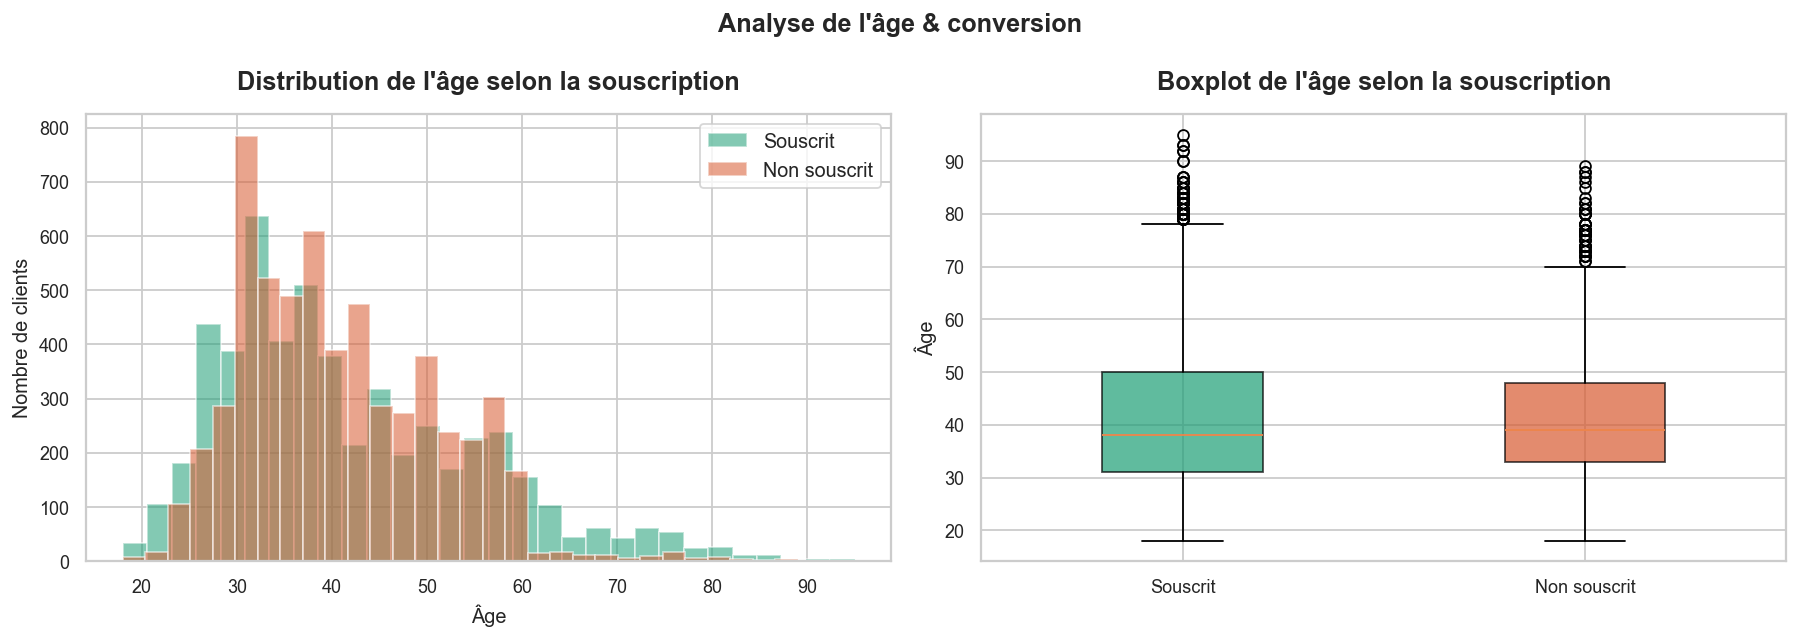

Âge moyen — Souscrit    : 41.7 ans
Âge moyen — Non souscrit : 40.8 ans


In [31]:
# --- Distribution de l'âge selon la conversion ---
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# KDE
for val, color, label in [
    ("yes", COLOR_YES, "Souscrit"),
    ("no", COLOR_NO, "Non souscrit"),
]:
    subset = df[df["subscribed"] == val]["age"]
    axes[0].hist(
        subset, bins=30, alpha=0.55, color=color, label=label, edgecolor="white"
    )
axes[0].set_title("Distribution de l'âge selon la souscription")
axes[0].set_xlabel("Âge")
axes[0].set_ylabel("Nombre de clients")
axes[0].legend()

# Box plot
age_data = [df[df["subscribed"] == "yes"]["age"], df[df["subscribed"] == "no"]["age"]]
bp = axes[1].boxplot(
    age_data, patch_artist=True, labels=["Souscrit", "Non souscrit"], widths=0.4
)
for patch, color in zip(bp["boxes"], COLORS_DUAL):
    patch.set_facecolor(color)
    patch.set_alpha(0.7)
axes[1].set_title("Boxplot de l'âge selon la souscription")
axes[1].set_ylabel("Âge")

plt.suptitle("Analyse de l'âge & conversion", fontsize=14, fontweight="bold")
plt.tight_layout()
plt.savefig(
    os.path.join("..", "outputs", "figures", "05_age_vs_conversion.png"),
    dpi=150,
    bbox_inches="tight",
)
plt.show()

print(
    f"Âge moyen — Souscrit    : {df[df['subscribed'] == 'yes']['age'].mean():.1f} ans"
)
print(
    f"Âge moyen — Non souscrit : {df[df['subscribed'] == 'no']['age'].mean():.1f} ans"
)

---
## Analyse du timing de la campagne

> Quel mois et quel canal génèrent le meilleur taux de conversion ?

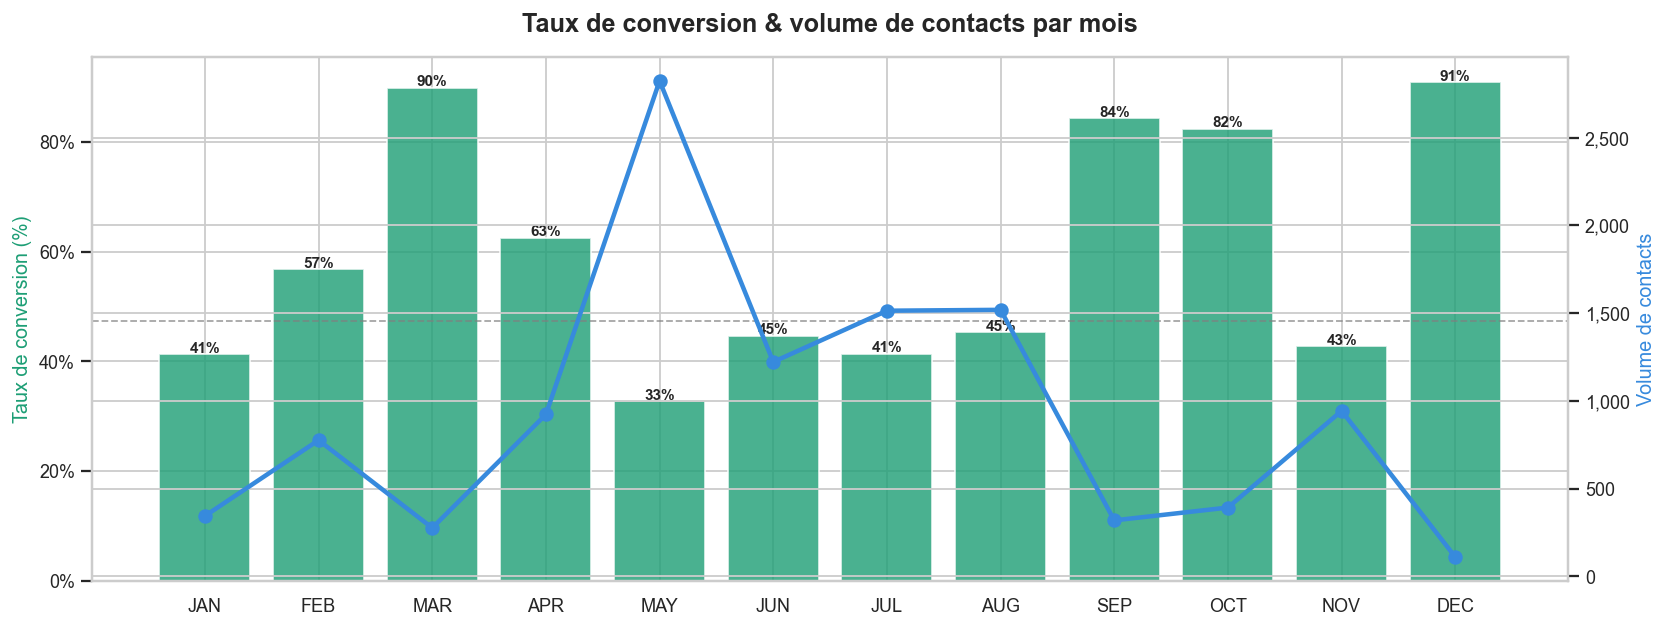


 Top 3 mois par taux de conversion :
            taux  nb_contacts
month                        
dec    90.909091          110
mar    89.855072          276
sep    84.326019          319


In [45]:
# --- Par mois ---
grp_month = (
    df.groupby("month", observed=True)
    .agg(nb_contacts=("subscribed_bin", "count"), conversions=("subscribed_bin", "sum"))
    .assign(taux=lambda x: x["conversions"] / x["nb_contacts"] * 100)
)

fig, ax1 = plt.subplots(figsize=(13, 5))
ax2 = ax1.twinx()

x = range(len(grp_month))
bars = ax1.bar(
    x, grp_month["taux"], color=COLOR_YES, alpha=0.8, edgecolor="white", linewidth=1
)
ax2.plot(
    x,
    grp_month["nb_contacts"],
    color=COLOR_BASE,
    marker="o",
    linewidth=2.5,
    markersize=7,
)

for bar, val in zip(bars, grp_month["taux"]):
    ax1.text(
        bar.get_x() + bar.get_width() / 2,
        bar.get_height() + 0.3,
        f"{val:.0f}%",
        ha="center",
        fontsize=8.5,
        fontweight="bold",
    )

ax1.set_xticks(list(x))
ax1.set_xticklabels([m.upper() for m in grp_month.index], fontsize=10)
ax1.set_ylabel("Taux de conversion (%)", color=COLOR_YES)
ax1.yaxis.set_major_formatter(mtick.FuncFormatter(lambda y, _: f"{y:.0f}%"))
ax2.set_ylabel("Volume de contacts", color=COLOR_BASE)
ax2.yaxis.set_major_formatter(mtick.FuncFormatter(lambda y, _: f"{int(y):,}"))
ax1.axhline(
    df["subscribed_bin"].mean() * 100,
    color="gray",
    linestyle="--",
    linewidth=1,
    alpha=0.7,
)
ax1.set_title("Taux de conversion & volume de contacts par mois")
plt.tight_layout()
plt.savefig(
    os.path.join("..", "outputs", "figures", "06_conversion_par_mois.png"),
    dpi=150,
    bbox_inches="tight",
)
plt.show()

print("\n Top 3 mois par taux de conversion :")
print(grp_month[["taux", "nb_contacts"]].sort_values("taux", ascending=False).head(3))

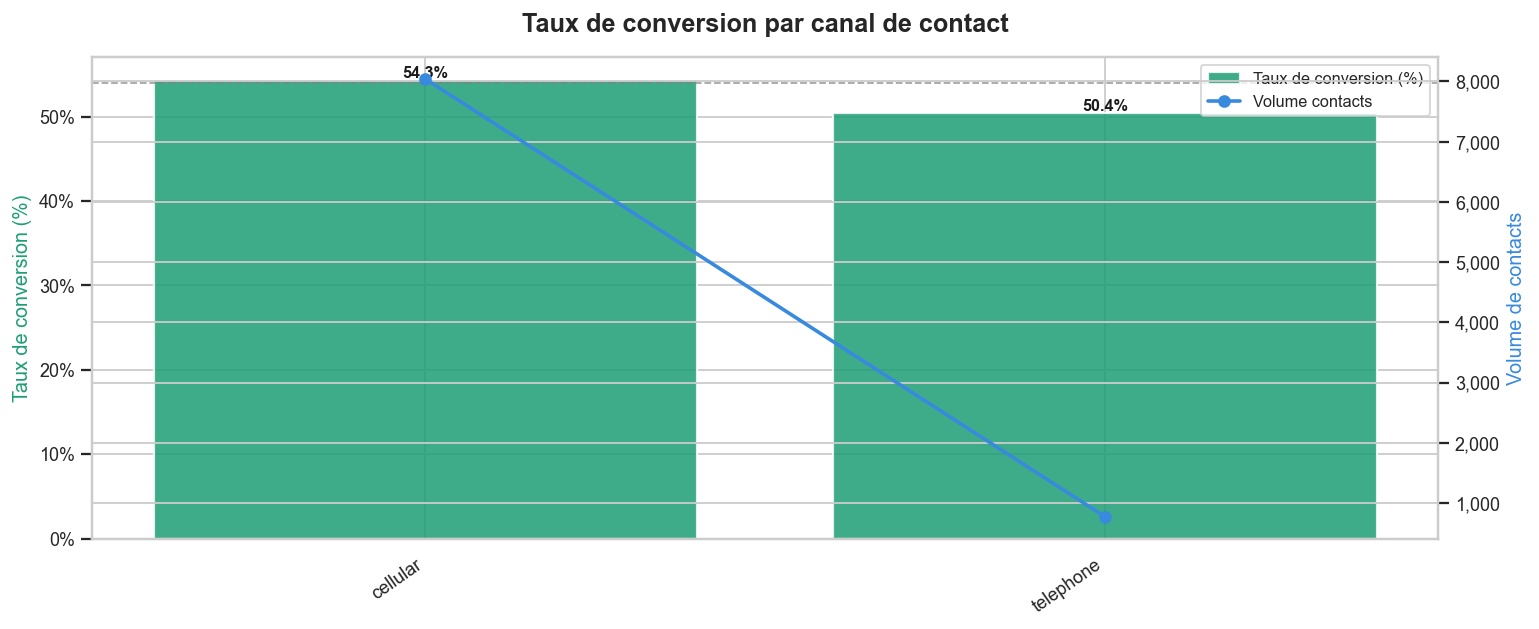


 Insight : Le canal cellulaire (mobile) convertit-il mieux que le téléphone fixe ?


In [33]:
# --- Par canal de contact ---
grp_contact = plot_conversion_by_cat(
    df.dropna(subset=["contact"]),
    "contact",
    title="Taux de conversion par canal de contact",
    save_name="07_conversion_par_canal.png",
)
print(
    "\n Insight : Le canal cellulaire (mobile) convertit-il mieux que le téléphone fixe ?"
)

---
## Point de saturation des contacts

> À partir de combien de relances la campagne devient-elle contre-productive ?

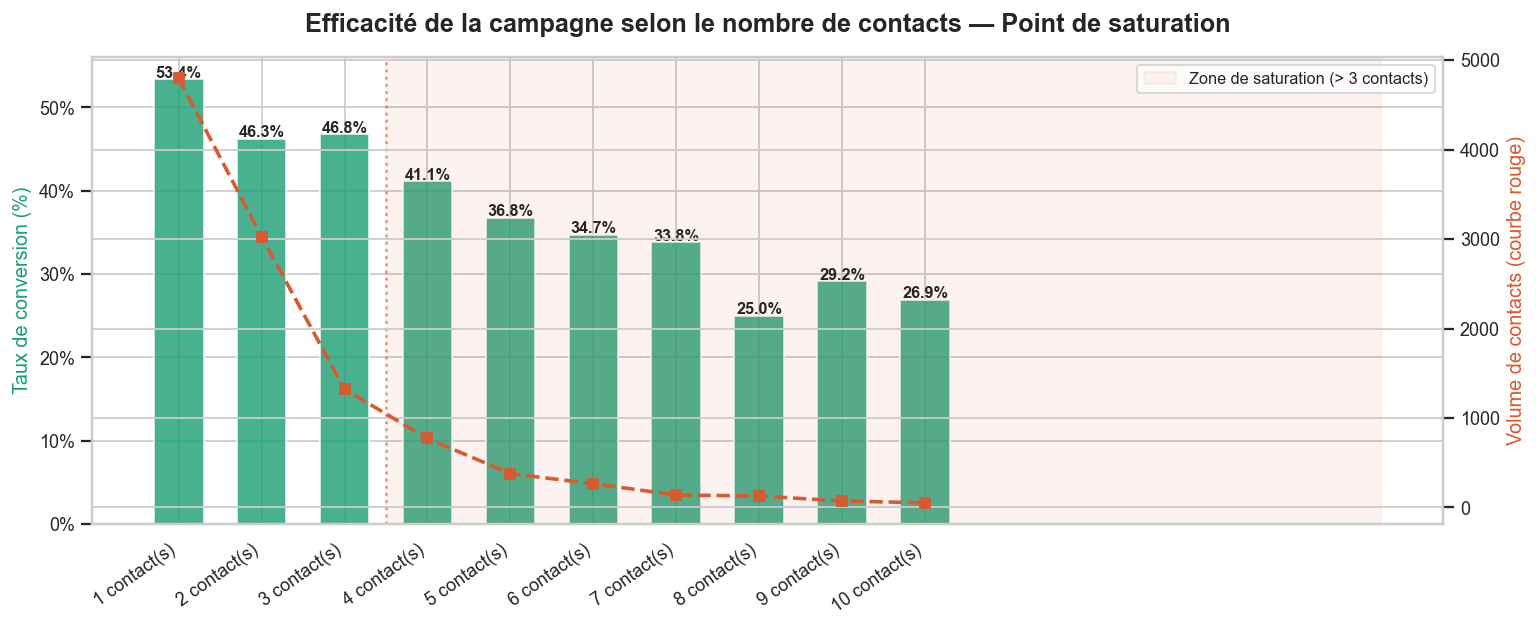


 Taux de conversion par nombre de contacts :


,Volume,Taux de conversion (%)
campaign,,
1,4798,53.376407
2,3028,46.268164
3,1321,46.782740
4,771,41.115435
5,378,36.772487
6,265,34.716981
7,139,33.812950
8,128,25.000000
9,72,29.166667


In [34]:
# Filtrer sur les volumes significatifs (>50 contacts)
saturation = (
    df.groupby("campaign")
    .agg(nb_contacts=("subscribed_bin", "count"), taux=("subscribed_bin", "mean"))
    .assign(taux=lambda x: x["taux"] * 100)
    .query("nb_contacts >= 50 and campaign <= 15")
)

fig, ax1 = plt.subplots(figsize=(12, 5))
ax2 = ax1.twinx()

x = saturation.index
bars = ax1.bar(
    x,
    saturation["taux"],
    color=COLOR_YES,
    alpha=0.8,
    edgecolor="white",
    linewidth=1,
    width=0.6,
)
ax2.plot(
    x,
    saturation["nb_contacts"],
    color=COLOR_NO,
    marker="s",
    linewidth=2,
    markersize=6,
    linestyle="--",
)

for bar, val in zip(bars, saturation["taux"]):
    ax1.text(
        bar.get_x() + bar.get_width() / 2,
        bar.get_height() + 0.2,
        f"{val:.1f}%",
        ha="center",
        fontsize=9,
        fontweight="bold",
    )

# Zone de saturation (à partir de 4 contacts)
ax1.axvspan(
    3.5, 15.5, alpha=0.07, color=COLOR_NO, label="Zone de saturation (> 3 contacts)"
)
ax1.axvline(3.5, color=COLOR_NO, linestyle=":", linewidth=1.5, alpha=0.6)

ax1.set_xticks(list(x))
ax1.set_xticklabels([f"{i} contact(s)" for i in x], rotation=35, ha="right")
ax1.set_ylabel("Taux de conversion (%)", color=COLOR_YES)
ax1.yaxis.set_major_formatter(mtick.FuncFormatter(lambda y, _: f"{y:.0f}%"))
ax2.set_ylabel("Volume de contacts (courbe rouge)", color=COLOR_NO)
ax1.set_title(
    "Efficacité de la campagne selon le nombre de contacts — Point de saturation"
)
ax1.legend(loc="upper right", fontsize=9)
plt.tight_layout()
plt.savefig(
    os.path.join("..", "outputs", "figures", "08_saturation_contacts.png"),
    dpi=150,
    bbox_inches="tight",
)
plt.show()

print("\n Taux de conversion par nombre de contacts :")
display(
    saturation[["nb_contacts", "taux"]].rename(
        columns={"nb_contacts": "Volume", "taux": "Taux de conversion (%)"}
    )
)

---
## Impact de la campagne précédente

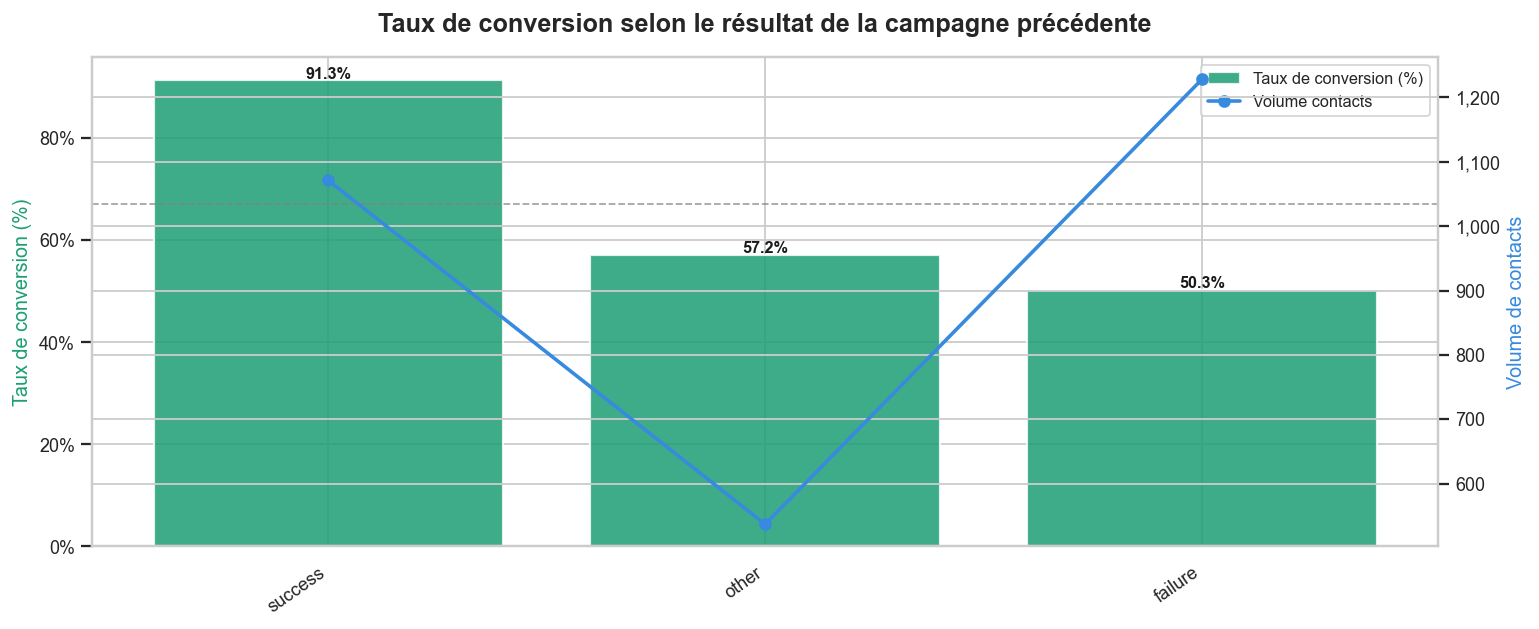


 Insight : Les clients ayant déjà souscrit convertissent-ils significativement plus ?


In [35]:
# --- Résultat campagne précédente ---
grp_pout = plot_conversion_by_cat(
    df.dropna(subset=["poutcome"]),
    "poutcome",
    title="Taux de conversion selon le résultat de la campagne précédente",
    save_name="09_impact_campagne_precedente.png",
)
print(
    "\n Insight : Les clients ayant déjà souscrit convertissent-ils significativement plus ?"
)

---
## Connexion à la base de données PostgreSQL

In [40]:
# psql toolkit
import psycopg2
from sqlalchemy import create_engine

user = "postgres"  # ou ton utilisateur défini dans le docker-compose
password = "postgres"  # idem
host = "localhost"
port = "5432"
database = "bank_marketing_campaign"

# Création de l'engine SQLAlchemy
engine = create_engine(f"postgresql://{user}:{password}@{host}:{port}/{database}")
try:
    engine
    print("Connection Successed to PSQL")
except:
    print("Unable to connect")

# Sauvegarde du DataFrame dans la table "manga"
df.to_sql(name="bank", con=engine, if_exists="replace", index=False)

Connection Successed to PSQL


162

---
## Synthèse des insights — Partie 1

> Récapitulatif des principaux enseignements à retenir avant de passer à la Partie 2.

In [36]:
# --- Tableau de synthèse automatique ---
best_job = grp_job["taux"].idxmax()
best_month = grp_month["taux"].idxmax()
best_contact = grp_contact["taux"].idxmax() if not grp_contact.empty else "N/A"
saturation_pt = saturation["taux"].diff().lt(0).idxmax()

insights = {
    " Taux de conversion global": f"{conv_rate:.1f}%",
    " Job avec le meilleur taux": f"{best_job} ({grp_job.loc[best_job, 'taux']:.1f}%)",
    " Mois avec le meilleur taux": f"{str(best_month).upper()} ({grp_month.loc[best_month, 'taux']:.1f}%)",
    " Canal le plus efficace": str(best_contact),
    " Point de saturation (nb contacts)": f"À partir de {saturation_pt} contacts",
    " Levier campagne précédente": "Clients ayant déjà souscrit = priorité absolue",
}

print("=" * 55)
print("    SYNTHÈSE INSIGHTS — PARTIE 1")
print("=" * 55)
for k, v in insights.items():
    print(f"   {k:<42} {v}")
print("=" * 55)
print("\n➡️  Prochaine étape : Partie 2 — Segmentation & LTV")

    SYNTHÈSE INSIGHTS — PARTIE 1
    Taux de conversion global                 47.4%
    Job avec le meilleur taux                 student (74.7%)
    Mois avec le meilleur taux                DEC (90.9%)
    Canal le plus efficace                    cellular
    Point de saturation (nb contacts)         À partir de 2 contacts
    Levier campagne précédente                Clients ayant déjà souscrit = priorité absolue

➡️  Prochaine étape : Partie 2 — Segmentation & LTV


In [37]:
# --- Sauvegarde des données nettoyées ---
processed_path = os.path.join("..", "data", "processed", "bank_clean.csv")
df.to_csv(processed_path, index=False)
print(f"Données nettoyées sauvegardées → {processed_path}")

✅ Données nettoyées sauvegardées → ../data/processed/bank_clean.csv
